# Connect two consecutive sections
Suppose we have partitioned the input circuit $C$ into section $C_1, C_2, \ldots, C_k$, s.t. the Interaction graph of each $C_i$, written $IG(C_i)$, is embeddable into the architecture $AG$. We now need transform these subcircuits onto $AG$.

We implement $C$ as a dag, and obtain a list of sub-dagcircuits $dag_1, dag_2, \ldots, dag_k$ as the output of our partition function. Furthermore, we realign the boundary nodes of consecutive dags so that their graph connections are simpler. I believe this partition could unveil more (dynamic) graph properties of quantum circuits, e.g., change of their completeness, change of their centres, etc.

The aim of this note is to link these connective sections so that the number of SWAPs inserted is minimal. A standard approach is as follows: 
(i) we select an initial mapping $m_1$ for $C_1$ which is good embedding of $IG(C_1$) in certain sense; 
(ii) assume that we have transformed i sections and the final mapping is $m_i$ (which is an embedding of $IG(C_i)$), we should find an embedding $m_{i+1}$ for $IG(C_{i+1})$ and a set of SWAPs that link $m_i$ to $m_{i+1}$. 
The objective is to minimise the number of total SWAPs inserted. 

$IG(C_i) \Rightarrow IG(C_{i+1})$?


## The general case
Suppose we have two sections $C_1$ and $C_2$ and the initial mapping of $C_1$ is a trivial mapping $id_Q$. The task is to find an embedding $m$ of $C_2$ s.t. the routing cost from $id$ to $m$ is minimal among all embeddings of $C_2$. This requires to examine all embeddings of $C_2$ if we use approximate token swapper (ATS) directly.

In general, let $m_1$ be an embedding of $IG(C_1)$ and $m_2$ an embedding of $IG(C_2)$. How to call ATS?

Let $Q_1$, $Q_2$ be subsets of $V$ and $m_i: Q_i \to V$ two 1-1 mappings for $i=1,2$.  

First, we apply $m_1$ on all gates in $C$, such that if $CX(i,j)$ in $C$, then we put $CX(m_1(i),m_1(j))$ in $m_1(C)$. In this way, the trivial mapping $id$ can embed $IG(m_1(C_1))$ to $AG$.

In the following, we assume $m_1=id_{Q_1}$. One issue is that each $Q_i$ is a subset of $V$ and $Q_1$ and $Q_2$ sometimes partially overlap.

In [1]:
from qiskit.transpiler.passes.routing.algorithms.token_swapper import ApproximateTokenSwapper as ATS
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.dagcircuit import DAGCircuit, DAGOpNode, DAGInNode, DAGOutNode
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit.transpiler.layout import Layout
from qiskit.circuit.quantumregister import Qubit
from qiskit.visualization import dag_drawer
from qiskit.qasm import Qasm

import matplotlib.pyplot as plt
import networkx as nx
import rustworkx as rx

In [2]:
def glue_map(map1_1, map2_1, coupling_graph):
    Pqubit = len(coupling_graph.nodes())
    map1 = copy.deepcopy(map1_1)
    map2 = copy.deepcopy(map2_1)
    print(map1)
    print(map2)
    for key, value in map1.items():
        if key not in map2 and value not in map2.values():
            map2[key] = value
    print(map2)
    notmap = []
    notocc = []
    for i in range(Pqubit):
        if i not in map2:
            notmap.append(i)
        if i not in map2.values():
            notocc.append(i)
    for item in notmap:
        tmp_n = random.choice(notocc)
        map2[item] = tmp_n
        notocc.remove(tmp_n)
 
    reverse_map2 = {v: k for k, v in map2.items()}
    
    graph_first_edge = []
    for item in coupling_graph.edges():
        graph_first_edge.append((reverse_map2[item[0]], reverse_map2[item[1]], 1))
        print(f'added {item} as edge {(reverse_map2[item[0]], reverse_map2[item[1]], 1)}')
    
    print(graph_first_edge)
    
    graph_first = rx.PyGraph()
    graph_first.add_nodes_from(range(Pqubit))
    graph_first.add_edges_from(graph_first_edge)
    
    print(graph_first)
    
    map1_new = dict()
    for key, value in map1.items():
        map1_new[key] = reverse_map2[value]
    print(map1_new)
    
    token_swapper = ATS(graph_first)
    glue_swap = token_swapper.map(map1_new)
    return glue_swap

In [3]:
def get_reverse_mapping(map1):
    revmap = dict()
    for key in map1:
        revmap[map1[key]] = key
    return revmap

def get_rxgraph(graph):
    if not isinstance(graph,nx.Graph):
        raise Exception (f'The input {type(graph)} should be a nx.Graph')
    rxgraph = rx.PyGraph()
    rxedges = [(edge[0],edge[1],1) for edge in graph.edges()]
    rxgraph.add_nodes_from(graph.nodes())
    rxgraph.add_edges_from(rxedges)
    return rxgraph

def token_swap(t2nmap, rxAG):
    """t2nmap is a mapping from token to nodes, rxAG is the rx version of AG"""
    token_swapper = ATS(rxAG)
    map1 = get_reverse_mapping(t2nmap)
    action = token_swapper.map(map1)
    return action

def ats_rotuer(t2n1, t2n2, rxAG):
    """//TODO: What if t2n1 and t2n2 are partial?"""
    for v in rxAG.nodes():
        if v not in t2n1:
            t2n1[v] = v
        if v not in t2n2:
            t2n2[v] = v
    
    t2n1_inv = get_reverse_mapping(t2n1)
    t2n = dict()
    for v in rxAG.nodes():
        t2n[v] = t2n2[t2n1_inv[v]]
    print(f'the composed mapping is {t2n}')
    return token_swap(t2n, rxAG)

[(0, 1), (0, 2), (1, 3), (2, 3), (2, 4), (3, 5), (4, 5)]


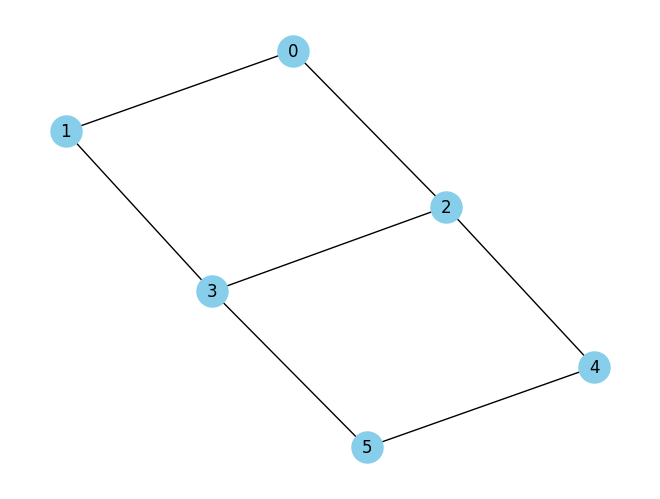

the composed mapping is {0: 3, 1: 1, 2: 4, 3: 2, 4: 0, 5: 5}
EdgeList[(3, 2), (0, 2), (4, 2)]


In [7]:
from ag import qgrid, q20
import time, os, copy, random

"""Divide-and-Conquer works fine on Tokyo and phase_estimation, phase_oracle, AND, OR, """
path = '../bench/qiskit_circuit_benchmark/' 
#filename = 'excitation_preserving_10.qasm'
#filename = 'grover_operator_10.qasm'
filename = 'and_5.qasm'

AG = qgrid(2,3)
#AG = q20()
print(AG.edges)
# Create a layout for the nodes
pos = nx.spring_layout(AG) #sl !!not sure if this is the correct layout for us!!
# Draw the nodes and edges
nx.draw(AG, pos, with_labels=True, node_color='skyblue', node_size=500, font_size=12, font_color='black')
# Display the graph
plt.show()

rxAG = get_rxgraph(AG)
"""It seems that map here is from node to token, 0:2, say, denotes that the token on node 0 is 2"""
"""If map1 = {0: 2, 2: 4, 4:0} then action is EdgeList[(2, 4), (2, 0)] """
"""If map1 = {2: 0, 4: 2, 0:4} then action is EdgeList[(0, 2), (2, 4)] """

map1 = {0: 2, 2: 4, 4:0}
#print(token_swap(map1,rxAG))

t2n1 = {3:2, 2:3}
#t2n2 = {2:0, 4:2, 0:4}
t2n2 = {4:0, 3:4, 0:3}

print(ats_rotuer(t2n1, t2n2, rxAG))